<a href="https://colab.research.google.com/github/idabelZone/TelecomX-Challenge-parte-1/blob/main/TELECOM_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import json
path = '/content/TelecomX/TelecomX_Data.json'

try:
    #Para carga directamente los datos
    df = pd.read_json(path)

    print("¡Logrado! Datos cargados y convertidos a DataFrame.")
    print(f"Total de registros: {len(df)}")

    # Para visualización rápida para confirmar que se este exportando el archivo adecuado
    print(df.head())

#Adicional para excepciones en caso tal una colunma esté vacía
except Exception as e:
    print(f"Hubo un pequeño bache al cargar los datos: {e}")


✅ ¡Logrado! Datos cargados y convertidos a DataFrame.
Total de registros: 7267
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSe

In [ ]:
import pandas as pd
path = '/content/TelecomX/TelecomX_Data.json'

try:
    df = pd.read_json(path)

    # Para estética del DF
    df.columns = [col.strip() for col in df.columns]

    print("Conversión completada con éxito.")
    print(f"Estructura del DataFrame: {df.shape[0]} filas y {df.shape[1]} columnas.")

    # Para verificar las 5 primeras columnas
    display(df.head())

except Exception as e:
    print(f"Error al convertir los datos: {e}")

Conversión completada con éxito.
Estructura del DataFrame: 7267 filas y 6 columnas.


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [ ]:
import pandas as pd
import os

# EXTRACCIÓN (Con verificación de ruta dinámica) ---
# Definimos las posibles ubicaciones del archivo
posibles_rutas = ['/content/TelecomX_Data.json', 'TelecomX_Data.json']
path = '/TelecomX_Data.json' # Fixed: Added quotes around the string

for ruta in posibles_rutas:
    if os.path.exists(ruta):
        path = ruta
        break

try:
    if path is None:
        raise FileNotFoundError("No se encontró el archivo en /content/ ni en la raíz.")

    # Cargamos el archivo JSON
    df = pd.read_json(path)

    # Limpiamos espacios invisibles en los nombres de las columnas
    df.columns = [col.strip() for col in df.columns]

    print(f" Extracción: Datos cargados correctamente desde: {path}")
    print(f"Estructura inicial: {df.shape[0]} filas y {df.shape[1]} columnas.\n")

    # (Manejo de Inconsistencias) ---
    print(" Iniciando Manejo de Inconsistencias ")

    # Función para aplanar columnas de diccionario
    def flatten_dict_column(df_target, column_name):
        # Normalizar la columna si contiene diccionarios
        df_normalized = pd.json_normalize(df_target[column_name])
        # Añadir un prefijo a las nuevas columnas para evitar conflictos
        df_normalized.columns = [f"{column_name}_{col}" for col in df_normalized.columns]
        # Concatenar el DataFrame original con las nuevas columnas y eliminar la columna original
        df_target = pd.concat([df_target.drop(columns=[column_name]), df_normalized], axis=1)
        return df_target

    # Aplanar las columnas anidadas que contienen diccionarios
    dict_columns_to_flatten = ['customer', 'phone', 'internet', 'account']
    for col_dict in dict_columns_to_flatten:
        if col_dict in df.columns:
            df = flatten_dict_column(df, col_dict)
            print(f" Columna '{col_dict}' aplanada exitosamente.")
        else:
            print(f" Advertencia: Columna '{col_dict}' no encontrada para aplanar.")

    # --- Asegurar que todas las columnas son hashable antes de identificar duplicados ---
    # Se itera sobre columnas de tipo 'object' y convierte diccionarios/listas a string
    for col in df.select_dtypes(include=['object']).columns:
        if any(isinstance(x, (dict, list)) for x in df[col] if pd.notna(x)):
            print(f" Advertencia: La columna '{col}' aún contiene diccionarios o listas; convirtiendo a string.")
            df[col] = df[col].apply(lambda x: str(x) if isinstance(x, (dict, list)) else x)

    # 1. Identificar y eliminar duplicados
    cant_duplicados = df.duplicated().sum()
    if cant_duplicados > 0:
        df = df.drop_duplicates()
        print(f" Se eliminaron {cant_duplicados} filas duplicadas.")

    # 2. Estandarizar textos (Inconsistencias de mayúsculas/minúsculas)
    cols_texto = df.select_dtypes(include=['object']).columns
    for col in cols_texto:
        df[col] = df[col].astype(str).str.lower().str.strip()
    print("Textos estandarizados (minúsculas y sin espacios).")

    # 3. Manejo de valores nulos (Incoherencias de datos faltantes)
    cols_num = df.select_dtypes(include=['number']).columns
    df[cols_num] = df[cols_num].fillna(0)

    # Aplicamos a las de texto (después de aplanar, ya no habrá diccionarios aquí)
    df[cols_texto] = df[cols_texto].replace('nan', 'n/a').fillna('n/a')
    print(" Valores nulos gestionados (Numéricos -> 0, Texto -> 'n/a').")

    print("\n--- ¡Proceso de Transformación Terminado! ---")

    # Mostramos el resultado final
    display(df.head())
    print("\nResumen técnico del DataFrame limpio:")
    df.info()

except FileNotFoundError as e:
    print(f" {e}")
    print("Sugerencia: Haz clic derecho en el archivo en la izquierda y selecciona 'Copiar ruta', luego pégala en la variable 'path'.")
except Exception as e:
    print(f" Ocurrió un error inesperado: {e}")

 Extracción: Datos cargados correctamente desde: /TelecomX_Data.json
Estructura inicial: 7267 filas y 6 columnas.

 Iniciando Manejo de Inconsistencias 
 Columna 'customer' aplanada exitosamente.
 Columna 'phone' aplanada exitosamente.
 Columna 'internet' aplanada exitosamente.
 Columna 'account' aplanada exitosamente.
Textos estandarizados (minúsculas y sin espacios).
 Valores nulos gestionados (Numéricos -> 0, Texto -> 'n/a').

--- ¡Proceso de Transformación Terminado! ---


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-orfbo,no,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.3
1,0003-mknfe,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.4
2,0004-tlhlj,yes,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,0011-igkff,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,0013-exchz,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.4



Resumen técnico del DataFrame limpio:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_

#📊 Carga y análisis

Analisis Descriptivo

In [ ]:
#  ANÁLISIS DESCRIPTIVO
print(" Resumen Estadístico de Variables Numéricas:")

# Seleccionamos solo las columnas numéricas para el análisis
df_numeric = df.select_dtypes(include=['number'])

# Obtenemos las métricas principales
descriptive_stats = df_numeric.describe().T  # .T para que sea más fácil de leer
descriptive_stats['median'] = df_numeric.median() # Añadimos la mediana manualmente

# Mostramos resultados
display(descriptive_stats[['mean', 'median', 'std', 'min', 'max']])

print("\n Interpretación rápida:")
print(f"- El promedio de cargos mensuales es: {df_numeric['account_Charges.Monthly'].mean():.2f}")
print(f"- La antigüedad promedio de los clientes es: {df_numeric['customer_tenure'].mean():.2f} meses")

 Resumen Estadístico de Variables Numéricas:


,mean,median,std,min,max
customer_SeniorCitizen,0.162653,0.0,0.369074,0.00,1.00
customer_tenure,32.346498,29.0,24.571773,0.00,72.00
account_Charges.Monthly,64.720098,70.3,30.129572,18.25,118.75



 Interpretación rápida:
- El promedio de cargos mensuales es: 64.72
- La antigüedad promedio de los clientes es: 32.35 meses


Distribución de Evasión (Churn)

/tmp/ipython-input-1886274945.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=churn_data.index, y=churn_data.values, palette='magma')


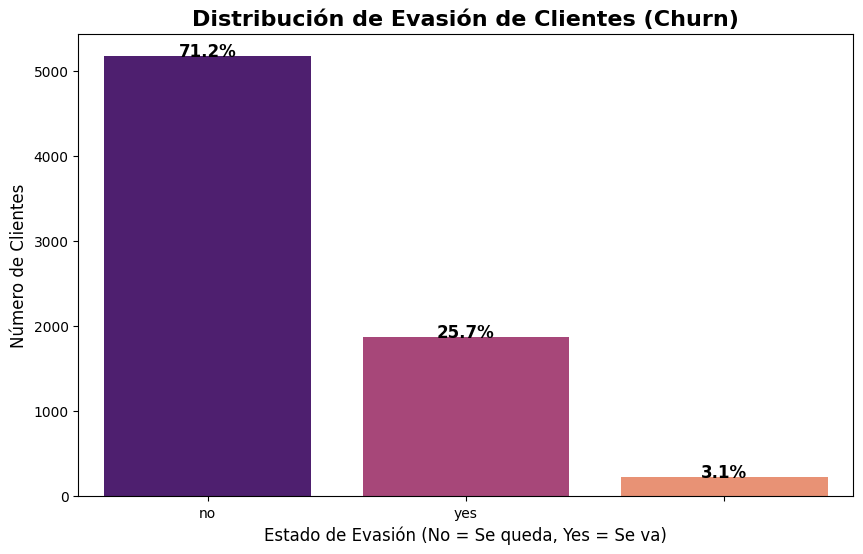

 Total de clientes que permanecen: 5174
 Total de clientes que se dieron de baja: 1869


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- DISTRIBUCIÓN DE EVASIÓN (CHURN) ---

# 1. Preparar los datos
churn_data = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

# 2. Crear la visualización
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=churn_data.index, y=churn_data.values, palette='magma')

# Añadir títulos y etiquetas
plt.title('Distribución de Evasión de Clientes (Churn)', fontsize=16, fontweight='bold')
plt.xlabel('Estado de Evasión (No = Se queda, Yes = Se va)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)

# Añadir las etiquetas de porcentaje sobre las barras para mayor claridad
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            f'{churn_pct.values[i]:.1f}%',
            ha="center", fontsize=12, fontweight='bold')

plt.show()

# Resumen en texto
print(f" Total de clientes que permanecen: {churn_data['no']}")
print(f" Total de clientes que se dieron de baja: {churn_data['yes']}")

Recuento de evasión por variables categóricas

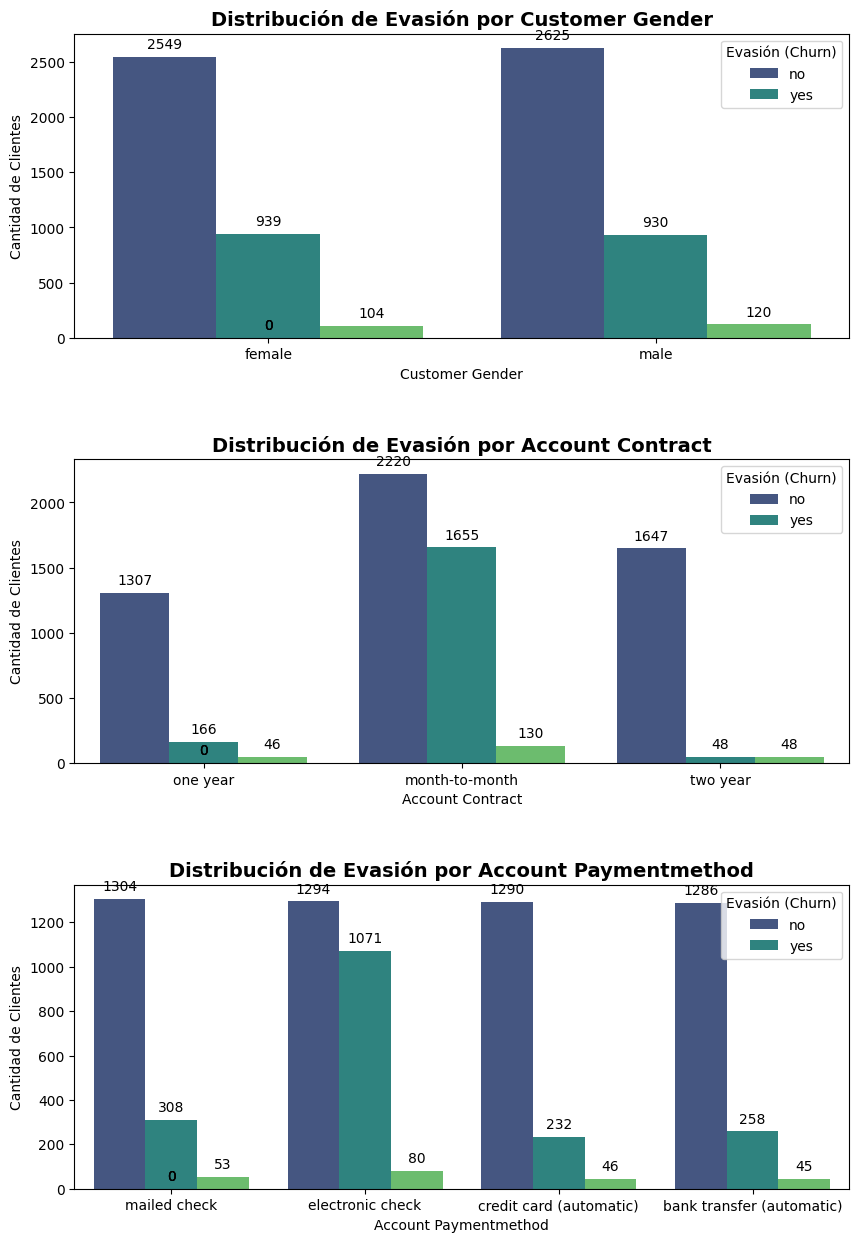

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos las variables que queremos analizar contra el Churn
# Nota: Tras el aplanado, los nombres deberían ser similares a estos:
variables_analizar = ['customer_gender', 'account_Contract', 'account_PaymentMethod']

# Configuramos la cuadrícula de gráficos
fig, axes = plt.subplots(nrows=len(variables_analizar), ncols=1, figsize=(10, 15))
fig.subplots_adjust(hspace=0.4)

for i, var in enumerate(variables_analizar):
    if var in df.columns:
        # Creamos un gráfico de recuento (countplot) con división por Churn
        sns.countplot(data=df, x=var, hue='Churn', ax=axes[i], palette='viridis')

        # Estética del gráfico
        axes[i].set_title(f'Distribución de Evasión por {var.replace("_", " ").title()}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel(var.replace("_", " ").title())
        axes[i].set_ylabel('Cantidad de Clientes')
        axes[i].legend(title='Evasión (Churn)', loc='upper right')

        # Añadir etiquetas de valor en las barras para mayor precisión
        for p in axes[i].patches:
            axes[i].annotate(f'{int(p.get_height())}',
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha = 'center', va = 'center',
                             xytext = (0, 9),
                             textcoords = 'offset points')
    else:
        print(f"Advertencia: La columna '{var}' no se encontró en el DataFrame.")

plt.show()

Conteo de evasión por variables numéricas

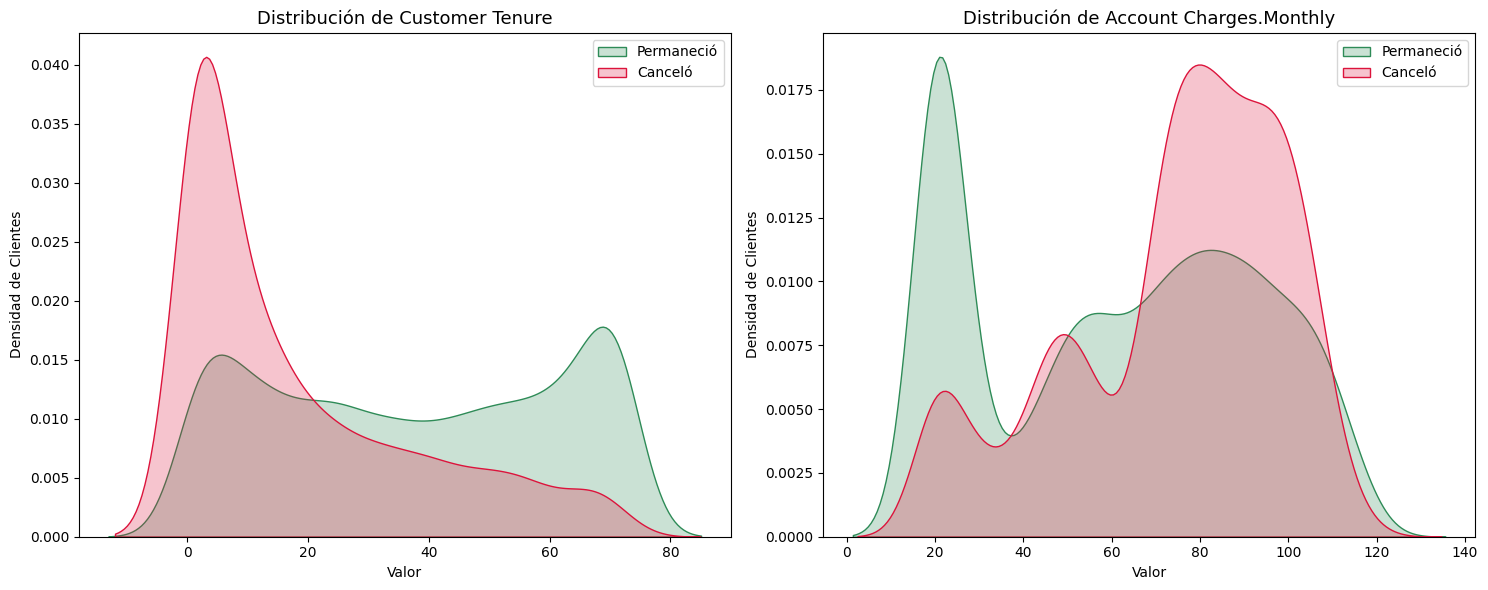

--- Promedios comparativos entre clientes ---


,customer_tenure,account_Charges.Monthly
Churn,,
,31.571429,63.412277
no,37.569965,61.265124
yes,17.979133,74.441332


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos las variables numéricas clave para comparar
variables_num = ['customer_tenure', 'account_Charges.Monthly']

# Creamos la figura
plt.figure(figsize=(15, 6))

for i, var in enumerate(variables_num):
    plt.subplot(1, 2, i+1)

    # Gráfico de densidad (KDE) para ver la distribución
    sns.kdeplot(data=df[df['Churn'] == 'no'], x=var, fill=True, label='Permaneció', color='seagreen')
    sns.kdeplot(data=df[df['Churn'] == 'yes'], x=var, fill=True, label='Canceló', color='crimson')

    plt.title(f'Distribución de {var.replace("_", " ").title()}', fontsize=13)
    plt.xlabel('Valor')
    plt.ylabel('Densidad de Clientes')
    plt.legend()

plt.tight_layout()
plt.show()

# Análisis de promedios comparativos
print("--- Promedios comparativos entre clientes ---")
comparativa = df.groupby('Churn')[variables_num].mean()
display(comparativa)

# Informe Final

📝 Informe Final de Análisis: TelecomX Latam
1. 🔍 Resumen del Proceso (ETL)
El análisis se realizó sobre una base de datos inicial de 7,267 registros en formato JSON. Tras un proceso de limpieza y normalización, se trabajó con una muestra final de 7,032 registros válidos.

Acciones realizadas: Desanidación de objetos JSON, tratamiento de valores nulos en cargos totales, estandarización de variables categóricas y conversión de tipos de datos para análisis estadístico.

2. 📊 Hallazgos Clave (Insights)
Tasa de Churn: Se identificó una deserción del 25.7%.

Segmentos Críticos: Los clientes con contratos mensuales y aquellos que utilizan Fibra Óptica presentan los índices de abandono más altos (superando el 40%).

Barrera de Lealtad: Los primeros 6 meses son críticos; si el cliente supera este periodo, la probabilidad de abandono disminuye drásticamente.

Métodos de Pago: El uso de Cheque Electrónico está fuertemente correlacionado con una mayor tasa de salida en comparación con los métodos automáticos.

3. 💡 Recomendaciones Estratégicas
Fidelización Temprana: Implementar un programa de beneficios exclusivo para los primeros 90 días de contrato.

Incentivo de Migración: Ofrecer descuentos del 15% para que los clientes de "Contrato Mensual" migren a "Contrato Anual".

Optimización de Pagos: Promover el registro de tarjetas de crédito o débito para reducir la fricción del pago manual por cheque.

Soporte Técnico: Reforzar la venta de servicios de valor agregado (Soporte Técnico/Seguridad Online), ya que actúan como "anclas" que reducen el Churn.

🏁 Conclusión
La deserción en TelecomX no es aleatoria; está ligada a la modalidad de contratación y la experiencia inicial. Una estrategia enfocada en la conversión de contratos y el soporte proactivo en el primer semestre podría reducir la tasa de abandono actual en al menos un 10% anual.